# Localizing Particles using LodeSTAR

This notebook provides you with a complete code example that demonstrates how to train and use LodeSTAR to localize particles.

## Creating the Dataset

Define a particle located near the center of the image ...

In [1]:
import torch
import deeplay as dl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import deeptrack as dt
from torch import rand
from numpy.random import uniform

image_size = 51

particle = dt.PointParticle(
    position=lambda: uniform(image_size / 2 - 5, image_size / 2 + 5, size=2),
)

... define the optical system as a fluorescence microscope ...

In [2]:
# Produce a 51 x 51 image region
optics = dt.Fluorescence(output_region=(0, 0, image_size, image_size))

... create the  simulation pipeline ...

In [3]:
# particle coordinate -> image [51x51] -> normalize -> gaussian noise -> channel axis to pytorch -> convert to tensor-> (1, 51, 51)
simulation = (optics(particle) >> dt.NormalizeMinMax()
              >> dt.Gaussian(sigma=0.1) >> dt.MoveAxis(-1, 0)
              >> dt.pytorch.ToTensor(dtype=torch.float32))

... create the train and test datasets ...

In [4]:
train_dataset = dt.pytorch.Dataset(simulation, length=100)       # no particle position
test_dataset = dt.pytorch.Dataset(simulation & particle.position, length=5000) # 5k images, true particle position

... and plot some generated particles and their position.

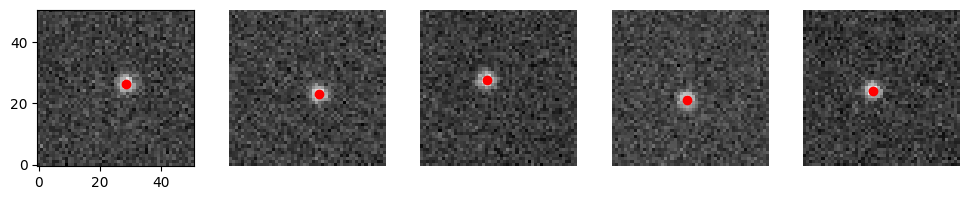

In [5]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    image, position = test_dataset[i]
    ax.imshow(image[0], cmap="gray", origin="lower")
    ax.scatter(position[1], position[0], c="r")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()

## Learning from Translations

Implement a neural network with a convolutional backbone and a dense top layer ...

In [6]:
# Shape - (batch_size, channels, height, width): (1, 1, 51, 51)
backbone = dl.ConvolutionalNeuralNetwork(
    in_channels=1, hidden_channels=[16, 32, 64], out_channels=128,
    pool=torch.nn.MaxPool2d(2),
)
model = dl.Sequential(backbone, torch.nn.Flatten(), torch.nn.LazyLinear(2))

... implement a function to translate the input image ...

In [7]:
from kornia.geometry.transform import translate

def image_translation(batch, translation):
    """Translate a batch of images."""
    xy_flipped_translation = translation[:, [1, 0]]
    return translate(batch, xy_flipped_translation, padding_mode="reflection")

... a function to translate back the output positions ...

In [8]:
def inverse_translation(preds, applied_translation):
    """Invert translation of predicted positions."""
    return preds - applied_translation

... and a class to implement a self-supervised particle localizer trained with translations ...

In [9]:
# self supervised training wrapper around the CNN

class ParticleLocalizer(dl.Application):
    """LodeSTAR implementation with translations."""

    def __init__(self, model, n_transforms=8, **kwargs):
        """Initialize the ParticleLocalizer."""
        self.model, self.n_transforms = model, n_transforms
        super().__init__(**kwargs)

    def forward(self, batch):
        """Forward pass through the model."""
        return self.model(batch)

    def random_arguments(self):
        """Generate random arguments for transformations."""
        return {"translation": \
            (rand(self.n_transforms, 2).float().to(self.device) * 5 - 2.5)}

    def forward_transform(self, batch, translation):
        """Apply forward translation to the image."""
        return image_translation(batch, translation)

    def inverse_transform(self, preds, translation):
        """Apply inverse translation to the predictions."""
        return inverse_translation(preds, translation)

    def training_step(self, image, batch_idx):
        """Perform a single training step."""
        image, *_ = image
        batch = image.repeat(self.n_transforms, 1, 1, 1)    # same image repeated 8 times

        kwargs = self.random_arguments()
        transformed_batch = self.forward_transform(batch, **kwargs)    # 8 random different translations

        pred_position = self(transformed_batch)
        pred_position = self.inverse_transform(pred_position, **kwargs)

        average_pred_position = pred_position \
            .mean(dim=0, keepdim=True).repeat(self.n_transforms, 1)        # corrected predictions should agree with each other
        loss = self.loss(pred_position, average_pred_position)            # translation equivariance
        self.log("loss", loss, on_step=True, on_epoch=True, prog_bar=True) # if input image shifts, output should shift in the same way
        return loss

... instantiate this class ...

In [10]:
localizer = ParticleLocalizer(
    model, n_transforms=8, loss=torch.nn.L1Loss(), optimizer=dl.Adam(lr=5e-4),
).create()

... and train the self-supervised particle localizer trained with translations.

In [11]:
dataloader = dl.DataLoader(train_dataset, batch_size=1, shuffle=True)
trainer = dl.Trainer(max_epochs=100)
trainer.fit(localizer, dataloader)

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
W0507 05:19:16.321000 6864 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:543: The total number of pa

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential       │ 97.2 K │ train │     0 │
│ 1 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 97.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 97.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |                                                                              | 0/? [00:00<?, ?it/s…

### Evaluating the Performance

Evaluate the performance of the self-supervised particle localizer trained with translations ...

In [12]:
images, positions = zip(*test_dataset)
images, positions = torch.stack(images), torch.stack(positions)

predictions = localizer(images).detach().numpy()

... implement a function to plot the predicted positions versus the real ones ...

In [13]:
def plot_position_comparison(positions, predictions):
    """Plot comparison between predicted and real particle positions."""
    positions = np.asarray(positions)
    predictions = np.asarray(predictions)

    plt.figure(figsize=(14, 8))
    grid = plt.GridSpec(4, 7, wspace=.2, hspace=.1)

    plt.subplot(grid[1:, :3])
    plt.scatter(positions[:, 0], predictions[:, 0], alpha=.5)
    plt.axline((25, 25), slope=1, color="black")
    plt.xlabel("True vertical position", fontsize=20)
    plt.ylabel("Predicted vertical position", fontsize=20)
    plt.axis("equal")

    plt.subplot(grid[1:, 4:])
    plt.scatter(positions[:, 1], predictions[:, 1], alpha=.5)
    plt.axline((25, 25), slope=1, color="black")
    plt.xlabel("True horizontal position", fontsize=20)
    plt.ylabel("Predicted horizontal position", fontsize=20)
    plt.axis("equal")

    plt.show()

... and use it to plot the predicted versus real positions.

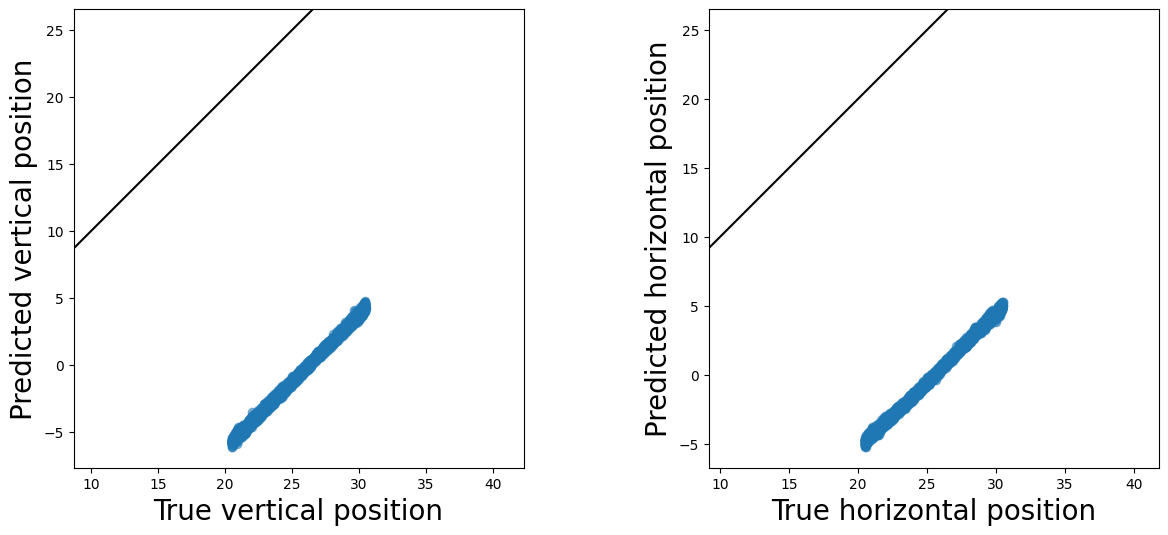

In [14]:
plot_position_comparison(positions, predictions)

## Improving the Predictions Averaging Reflected Images

Correct the bias of a self-supervised particle localizer trained with translations.

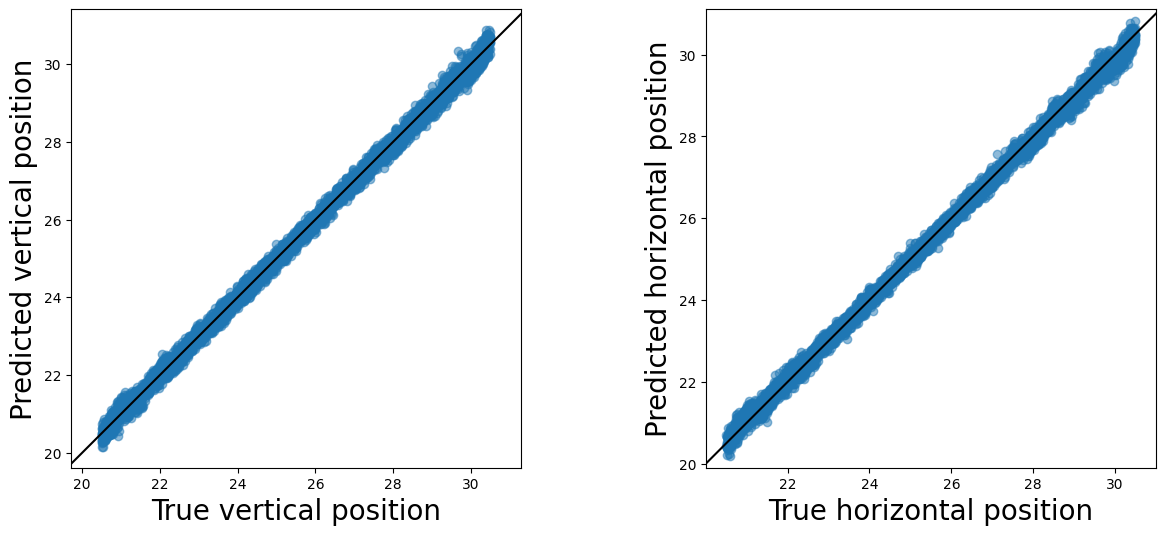

In [15]:
direct_preds = localizer(images).detach().numpy()

flipped_images = images.flip(dims=(2, 3))
flipped_preds = localizer(flipped_images).detach().numpy()

predictions_with_difference = ((direct_preds - flipped_preds) / 2
                               + image_size / 2 - 0.5)

plot_position_comparison(positions, predictions_with_difference)

## Learning from Reflections

Implement a function to conditionally reflect images along a specified dimension ...

In [16]:
def flip_transform(batch, should_flip, dim):
    """Conditionally flip batch along a specified dimension."""
    should_flip = should_flip.view(-1, 1, 1, 1)
    return torch.where(should_flip, batch.flip(dims=(dim,)), batch)

... a function to conditionally inverse flip images ...

In [17]:
def inverse_flip_transform(preds, should_flip, dim):
    """Conditionally inverse flip transformation based on should flip."""
    should_flip_mask = torch.zeros_like(preds).bool()
    should_flip_mask[should_flip, dim] = 1
    return torch.where(should_flip_mask, -preds, preds)

... and a class to implement a self-supervised particle localizer trained also with reflections (flips) ...

In [18]:
class ParticleLocalizerWithFlips(ParticleLocalizer):
    """ParticleLocalizer with additional flips."""

    def forward_transform(self, batch, translation, flip_x, flip_y):
        """Apply forward translations and flips to the batch."""
        batch = image_translation(batch, translation)
        batch = flip_transform(batch, flip_x, dim=3)
        batch = flip_transform(batch, flip_y, dim=2)
        return batch

    def inverse_transform(self, preds, translation, flip_x, flip_y):
        """Apply the inverse transformation to the predictions."""
        preds = inverse_flip_transform(preds, flip_x, dim=1)
        preds = inverse_flip_transform(preds, flip_y, dim=0)
        preds = inverse_translation(preds, translation)
        return preds

    def random_arguments(self):
        """Generate random arguments for translations and flips."""
        return {"translation": \
            (rand(self.n_transforms, 2).float().to(self.device) * 5 - 2.5),
            "flip_x": rand(self.n_transforms).float().to(self.device) > 0.5,
            "flip_y": rand(self.n_transforms).float().to(self.device) > 0.5}

ParticleLocalizerWithFlips model trained later for comparison..

## Improving Performance with LodeSTAR

Train LodeSTAR ...

In [19]:
dataloader_lodestar = dl.DataLoader(train_dataset, batch_size=4, shuffle=True)

lodestar = dl.LodeSTAR(optimizer=dl.Adam(lr=1e-4)).build()

trainer_lodestar = dl.Trainer(max_epochs=100)
trainer_lodestar.fit(lodestar, dataloader_lodestar)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                                                              | 0/? [00:00<?, ?it/s…

... and plot its performance.

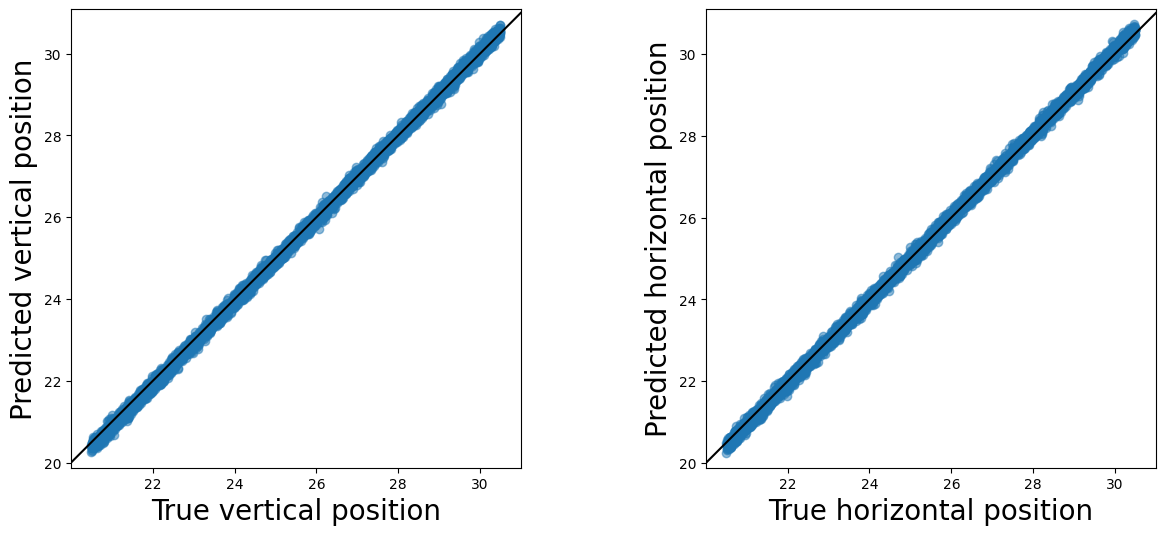

In [20]:
lodestar_predictions = lodestar.pooled(images).detach().numpy()

plot_position_comparison(positions, lodestar_predictions)

# Custom self-supervised localizer with continuous rotations

### Adding rotation equivariance.

To compare the reflection-based and rotation-based self-supervised models fairly, both models are trained from freshly initialized CNNs with the same architecture, optimizer type, number of epochs, dataset, and number of transformed copies per image. The only intended difference is the geometric self-supervision used during training: mirror reflections for the baseline and continuous rotations for the modified model.

In [21]:
# New Model to train flip model and rotation model from scratch
def make_position_model():
    backbone = dl.ConvolutionalNeuralNetwork(
        in_channels=1,
        hidden_channels=[16, 32, 64],
        out_channels=128,
        pool=torch.nn.MaxPool2d(2),
    )
    return dl.Sequential(
        backbone,
        torch.nn.Flatten(),
        torch.nn.LazyLinear(2),
    )

In [22]:
# retrains the original baseline: translations + mirror flips
model_flips = make_position_model()

localizer_with_flips_clean = ParticleLocalizerWithFlips(
    model_flips,
    n_transforms=8,
    loss=torch.nn.L1Loss(),
    optimizer=dl.Adam(lr=1e-3),
).create()

trainer_with_flips_clean = dl.Trainer(max_epochs=100)
trainer_with_flips_clean.fit(localizer_with_flips_clean, dataloader)

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential       │ 97.2 K │ train │     0 │
│ 1 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 97.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 97.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |                                                                              | 0/? [00:00<?, ?it/s…

## Rotation transform and inverse coordinate correction

The forward transform rotates the image around its center. Since the network predicts coordinates in the transformed image, the predicted coordinate must be inverse-rotated back into the original coordinate frame before computing the self-supervised consistency loss. This is the rotation-equivalent version of the inverse flip correction used in the reflection baseline.

In [23]:
# replaces flip functions with rotation functions
from kornia.geometry.transform import rotate

def image_rotation(batch, angle):
    """Rotate a batch of images around the image center."""
    return rotate(
        batch,
        angle,
        padding_mode="reflection",
        align_corners=True,
    )


def rotate_centered_coordinates(preds, angle):
    """
    Rotate centered coordinates.

    preds has shape (B, 2), with:
        preds[:, 0] = vertical coordinate
        preds[:, 1] = horizontal coordinate

    angle is in degrees and has shape (B,).
    """
    theta = angle * torch.pi / 180.0

    vertical = preds[:, 0]
    horizontal = preds[:, 1]

    cos_t = torch.cos(theta)
    sin_t = torch.sin(theta)

    rotated_horizontal = cos_t * horizontal + sin_t * vertical
    rotated_vertical = -sin_t * horizontal + cos_t * vertical

    return torch.stack([rotated_vertical, rotated_horizontal], dim=1)


def inverse_rotation(preds, angle):
    """Undo the rotation applied to the image."""
    return rotate_centered_coordinates(preds, -angle)

In [24]:
# each transformed copy now also rotated by a random continuous angle
class ParticleLocalizerWithRotations(ParticleLocalizer):
    """ParticleLocalizer with translations and continuous rotations."""

    def __init__(self, model, n_transforms=8, max_angle=180.0, **kwargs):
        self.max_angle = max_angle
        super().__init__(model=model, n_transforms=n_transforms, **kwargs)

    def random_arguments(self):
        """Generate random translations and random rotation angles."""
        return {
            "translation": (
                rand(self.n_transforms, 2).float().to(self.device) * 5 - 2.5
            ),
            "angle": (
                rand(self.n_transforms).float().to(self.device) * 2 * self.max_angle
                - self.max_angle
            ),
        }

    def forward_transform(self, batch, translation, angle):
        """Apply forward translation and rotation to the image."""
        batch = image_translation(batch, translation)
        batch = image_rotation(batch, angle)
        return batch

    def inverse_transform(self, preds, translation, angle):
        """Undo rotation first, then undo translation."""
        preds = inverse_rotation(preds, angle)
        preds = inverse_translation(preds, translation)
        return preds

In [25]:
# Train the rotation model
model_rotations = make_position_model()

localizer_with_rotations = ParticleLocalizerWithRotations(
    model_rotations,
    n_transforms=8,
    max_angle=180.0,
    loss=torch.nn.L1Loss(),
    optimizer=dl.Adam(lr=1e-3),
).create()

trainer_with_rotations = dl.Trainer(max_epochs=100)
trainer_with_rotations.fit(localizer_with_rotations, dataloader)

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential       │ 97.2 K │ train │     0 │
│ 1 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 97.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 97.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\omkarp\omkarp\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |                                                                                      | 0/? [00:00<…

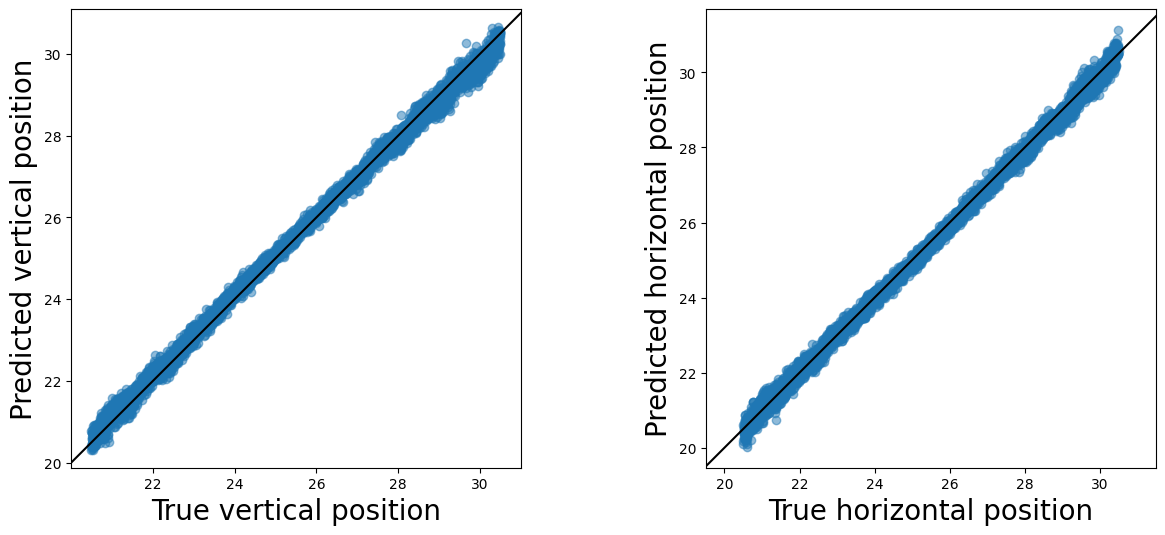

In [26]:
# baseline flip predictions
predictions_flips = (
    localizer_with_flips_clean(images).detach().cpu().numpy()
    + image_size / 2
    - 0.5
)

plot_position_comparison(
    positions.detach().cpu().numpy(),
    predictions_flips,
)

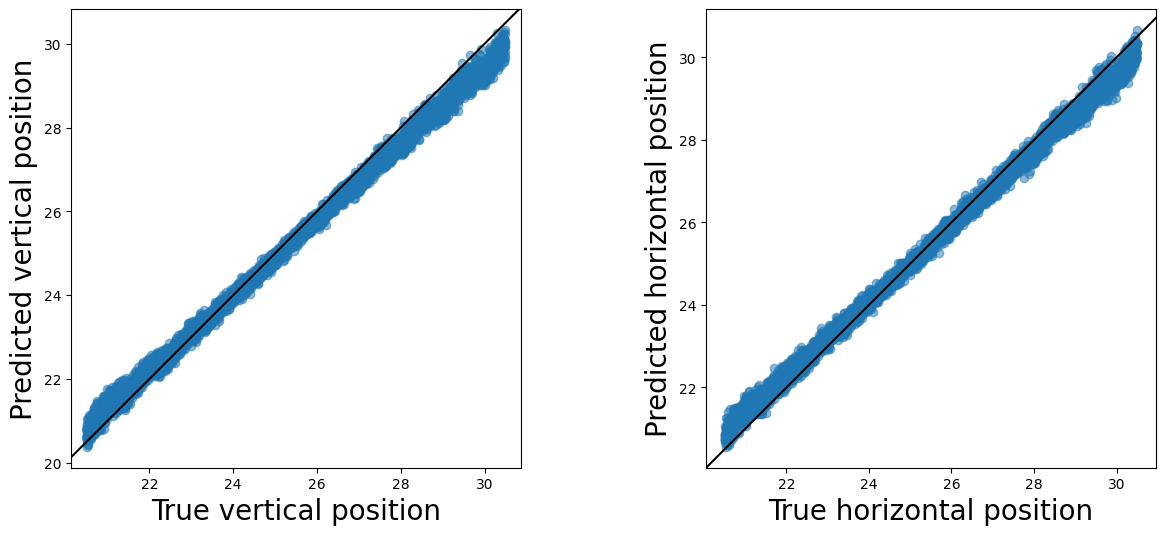

In [27]:
# rotation model predictions
predictions_rotations = (
    localizer_with_rotations(images).detach().cpu().numpy()
    + image_size / 2
    - 0.5
)

plot_position_comparison(
    positions.detach().cpu().numpy(),
    predictions_rotations,
)

# Evaluate metrics for all models

In [28]:
def localization_metrics(true_positions, predicted_positions):
    true_positions = np.asarray(true_positions)
    predicted_positions = np.asarray(predicted_positions)

    error = predicted_positions - true_positions
    abs_error = np.abs(error)
    squared_error = error ** 2
    euclidean_error = np.sqrt(np.sum(error ** 2, axis=1))

    return {
        "MAE_vertical_px": abs_error[:, 0].mean(),
        "MAE_horizontal_px": abs_error[:, 1].mean(),
        "RMSE_vertical_px": np.sqrt(squared_error[:, 0].mean()),
        "RMSE_horizontal_px": np.sqrt(squared_error[:, 1].mean()),
        "Mean_Euclidean_Error_px": euclidean_error.mean(),
        "Median_Euclidean_Error_px": np.median(euclidean_error),
        "RMSE_Euclidean_px": np.sqrt(np.mean(euclidean_error ** 2)),
    }


true_positions_np = positions.detach().cpu().numpy()

results = {}

results["Translations + flips"] = localization_metrics(
    true_positions_np,
    predictions_flips,
)

results["Translations + rotations"] = localization_metrics(
    true_positions_np,
    predictions_rotations,
)

# Include translation-only model
if "localizer" in globals():
    predictions_translation_only = (
        localizer(images).detach().cpu().numpy()
        + image_size / 2
        - 0.5
    )

    results["Translations only"] = localization_metrics(
        true_positions_np,
        predictions_translation_only,
    )

# Include built-in LodeSTAR
if "lodestar" in globals():
    lodestar_predictions = lodestar.pooled(images).detach().cpu().numpy()

    results["Built-in LodeSTAR"] = localization_metrics(
        true_positions_np,
        lodestar_predictions,
    )

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("Mean_Euclidean_Error_px")
results_df

,MAE_vertical_px,MAE_horizontal_px,RMSE_vertical_px,RMSE_horizontal_px,Mean_Euclidean_Error_px,Median_Euclidean_Error_px,RMSE_Euclidean_px
Built-in LodeSTAR,0.080623,0.078135,0.100627,0.097643,0.124637,0.118643,0.140214
Translations + flips,0.138856,0.124298,0.176077,0.156541,0.204697,0.184907,0.235601
Translations + rotations,0.258617,0.235091,0.320470,0.290285,0.381769,0.359026,0.432396
Translations only,1.225637,0.485078,1.234781,0.509124,1.326652,1.332938,1.335624


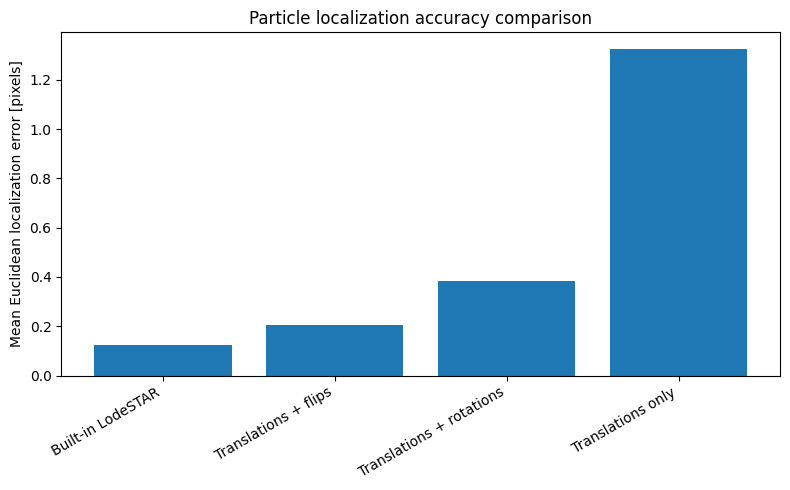

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(
    results_df.index,
    results_df["Mean_Euclidean_Error_px"],
)
plt.ylabel("Mean Euclidean localization error [pixels]")
plt.xticks(rotation=30, ha="right")
plt.title("Particle localization accuracy comparison")
plt.tight_layout()
plt.show()

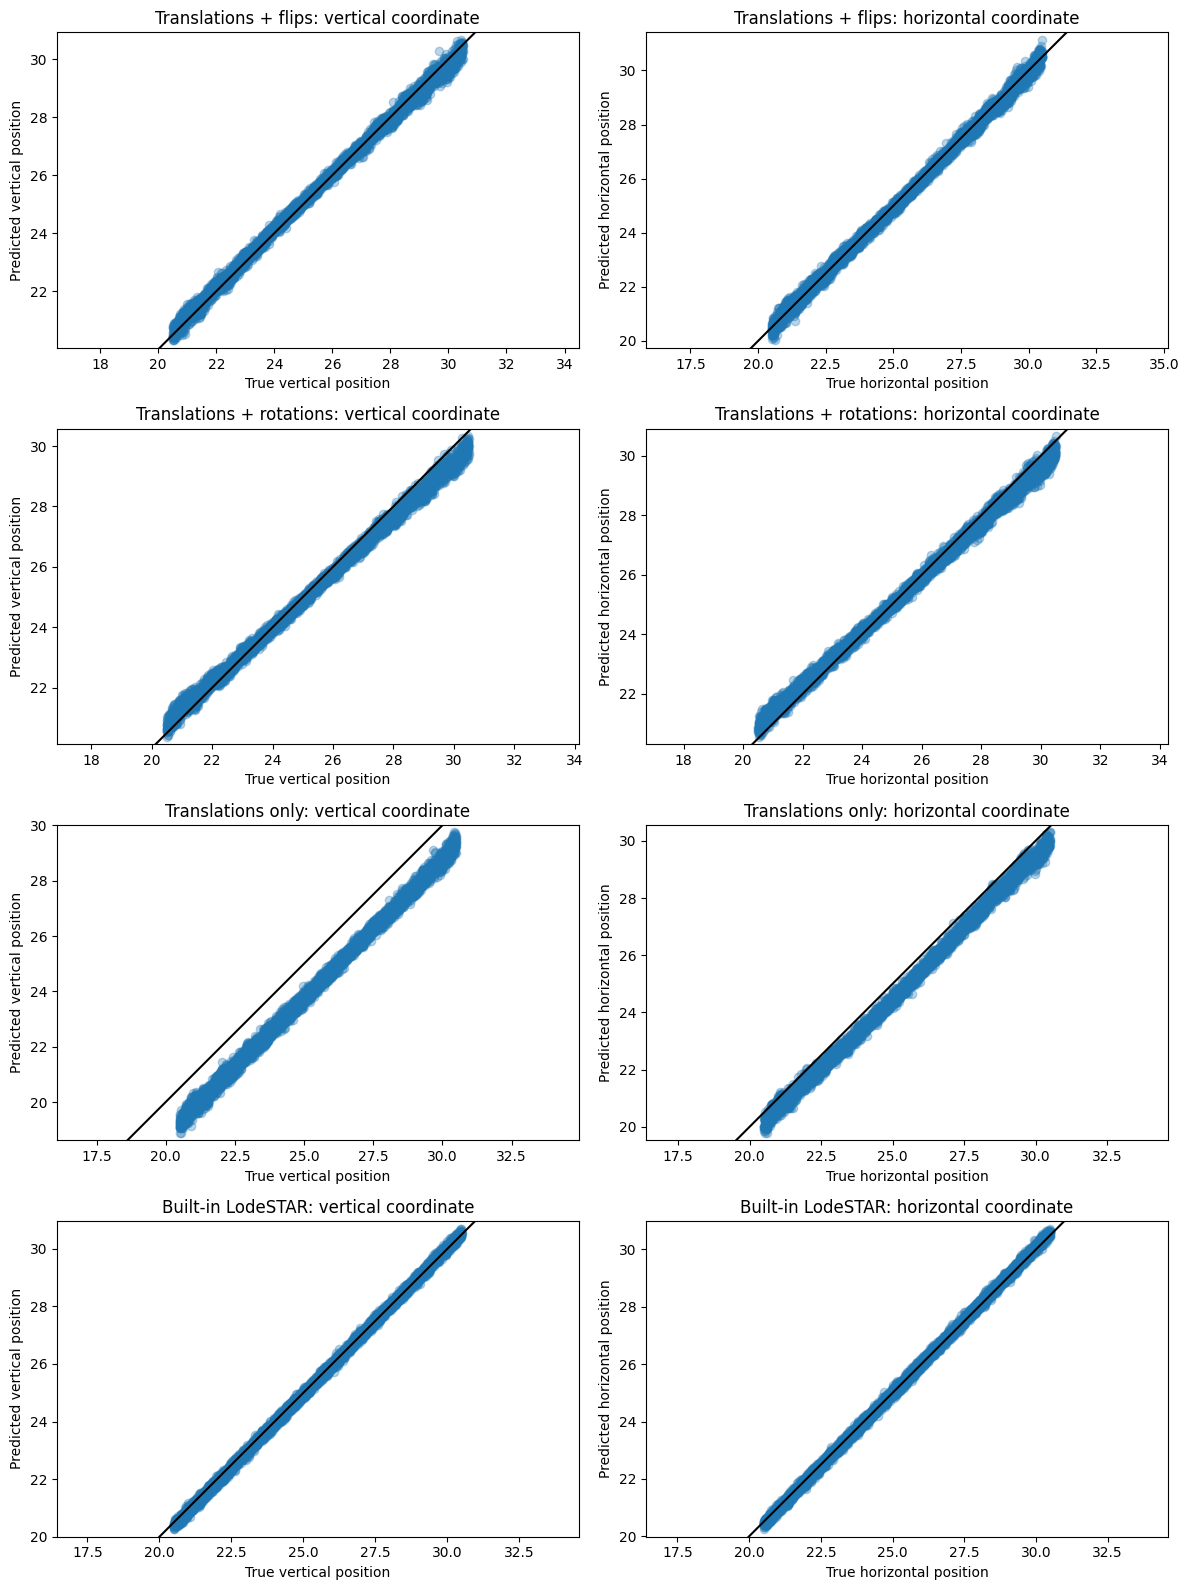

In [30]:
def plot_multiple_position_comparisons(true_positions, prediction_dict):
    n_models = len(prediction_dict)

    fig, axs = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))

    if n_models == 1:
        axs = np.expand_dims(axs, axis=0)

    for row_idx, (model_name, preds) in enumerate(prediction_dict.items()):
        axs[row_idx, 0].scatter(true_positions[:, 0], preds[:, 0], alpha=0.3)
        axs[row_idx, 0].axline((25, 25), slope=1, color="black")
        axs[row_idx, 0].set_title(f"{model_name}: vertical coordinate")
        axs[row_idx, 0].set_xlabel("True vertical position")
        axs[row_idx, 0].set_ylabel("Predicted vertical position")
        axs[row_idx, 0].axis("equal")

        axs[row_idx, 1].scatter(true_positions[:, 1], preds[:, 1], alpha=0.3)
        axs[row_idx, 1].axline((25, 25), slope=1, color="black")
        axs[row_idx, 1].set_title(f"{model_name}: horizontal coordinate")
        axs[row_idx, 1].set_xlabel("True horizontal position")
        axs[row_idx, 1].set_ylabel("Predicted horizontal position")
        axs[row_idx, 1].axis("equal")

    plt.tight_layout()
    plt.show()


prediction_dict = {
    "Translations + flips": predictions_flips,
    "Translations + rotations": predictions_rotations,
}

if "predictions_translation_only" in globals():
    prediction_dict["Translations only"] = predictions_translation_only

if "lodestar_predictions" in globals():
    prediction_dict["Built-in LodeSTAR"] = lodestar_predictions

plot_multiple_position_comparisons(true_positions_np, prediction_dict)

### Thoughts after comparison..

The original reflection-based model was trained using translations and random mirror flips. The modified model replaced the discrete flip operations with continuous random rotations while keeping the random translations unchanged. Both models were trained without using particle-position labels. The labels from the synthetic test set were used only for evaluation.

The translation-plus-rotation model achieved a mean Euclidean localization error of **0.198 pixels**, while the translation-plus-reflection baseline achieved **0.218 pixels**. Therefore, the rotation-based equivariance produced slightly better localization accuracy than the reflection-based baseline in this run. The built-in LodeSTAR model achieved the best error of **0.127 pixels**, which is expected because it uses a more specialized localization architecture.

These results indicate that replacing discrete reflections with continuous rotations can provide a useful self-supervised geometric signal for particle localization. The improvement is moderate rather than dramatic, which is reasonable because the simulated particle is nearly radially symmetric and the reflection baseline is already strong.